In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from algorithms.graph import is_independent
from algorithms.greedy import greedy_mis
from algorithms.genetic_algorithm import genetic_algorithm
from algorithms.tabu_search import tabu_search
from algorithms.cplex_mis import cplex_mis

In [2]:
medium_dir = project_root / "data" / "medium"

medium_instances = sorted(medium_dir.glob("*.npy"))

print(f"Broj medium instanci: {len(medium_instances)}")

for path in medium_instances:
    graph = np.load(path)
    print(path.name, "n =", len(graph))

Broj medium instanci: 40
medium_n25_01.npy n = 25
medium_n25_02.npy n = 25
medium_n25_03.npy n = 25
medium_n25_04.npy n = 25
medium_n25_05.npy n = 25
medium_n25_06.npy n = 25
medium_n25_07.npy n = 25
medium_n25_08.npy n = 25
medium_n25_09.npy n = 25
medium_n25_10.npy n = 25
medium_n30_01.npy n = 30
medium_n30_02.npy n = 30
medium_n30_03.npy n = 30
medium_n30_04.npy n = 30
medium_n30_05.npy n = 30
medium_n30_06.npy n = 30
medium_n30_07.npy n = 30
medium_n30_08.npy n = 30
medium_n30_09.npy n = 30
medium_n30_10.npy n = 30
medium_n40_01.npy n = 40
medium_n40_02.npy n = 40
medium_n40_03.npy n = 40
medium_n40_04.npy n = 40
medium_n40_05.npy n = 40
medium_n40_06.npy n = 40
medium_n40_07.npy n = 40
medium_n40_08.npy n = 40
medium_n40_09.npy n = 40
medium_n40_10.npy n = 40
medium_n50_01.npy n = 50
medium_n50_02.npy n = 50
medium_n50_03.npy n = 50
medium_n50_04.npy n = 50
medium_n50_05.npy n = 50
medium_n50_06.npy n = 50
medium_n50_07.npy n = 50
medium_n50_08.npy n = 50
medium_n50_09.npy n = 50


In [3]:
import cplex

print(cplex.__version__)

22.2.0.0


#### Određivanje optimuma pomoću CPLEX-a

Optimalna rešenja za medium instance određujemo pomoću CPLEX optimizacionog solvera. Dobijene optimalne vrednosti koriste se kao referentne vrednosti za poređenje sa rešenjima pohlepnog algoritma, genetskog algoritma i tabu pretrage.

In [5]:
cplex_results = []

for path in medium_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = cplex_mis(graph)

    elapsed = time.perf_counter() - start

    cplex_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "CPLEX",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

cplex_results = pd.DataFrame(cplex_results)

cplex_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,medium_n25_01,25,CPLEX,8,0.007849,True
1,medium_n25_02,25,CPLEX,9,0.005937,True
2,medium_n25_03,25,CPLEX,9,0.005928,True
3,medium_n25_04,25,CPLEX,8,0.009929,True
4,medium_n25_05,25,CPLEX,7,0.006633,True
5,medium_n25_06,25,CPLEX,8,0.006991,True
6,medium_n25_07,25,CPLEX,8,0.007113,True
7,medium_n25_08,25,CPLEX,8,0.006249,True
8,medium_n25_09,25,CPLEX,8,0.009419,True
9,medium_n25_10,25,CPLEX,8,0.005319,True


In [7]:
print("Broj instanci:", len(cplex_results))
print("Nevalidna rešenja:", (~cplex_results["Valid"]).sum())
print("Najduže vreme:", cplex_results["Time (s)"].max())

Broj instanci: 40
Nevalidna rešenja: 0
Najduže vreme: 0.1138974989989947


#### Greedy algoritam na medium instancama

In [9]:
greedy_results = []

for path in medium_instances:
    graph = np.load(path)

    start = time.perf_counter()
    solution = greedy_mis(graph)
    elapsed = time.perf_counter() - start

    greedy_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Greedy",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

greedy_results = pd.DataFrame(greedy_results)

greedy_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,medium_n25_01,25,Greedy,8,0.000477,True
1,medium_n25_02,25,Greedy,9,0.000450,True
2,medium_n25_03,25,Greedy,9,0.000453,True
3,medium_n25_04,25,Greedy,8,0.000424,True
4,medium_n25_05,25,Greedy,7,0.000359,True
5,medium_n25_06,25,Greedy,8,0.000385,True
6,medium_n25_07,25,Greedy,8,0.000399,True
7,medium_n25_08,25,Greedy,8,0.000487,True
8,medium_n25_09,25,Greedy,7,0.000382,True
9,medium_n25_10,25,Greedy,8,0.000387,True


In [10]:
print("Broj instanci:", len(greedy_results))
print("Nevalidna rešenja:", (~greedy_results["Valid"]).sum())
print("Najduže vreme:", greedy_results["Time (s)"].max())

Broj instanci: 40
Nevalidna rešenja: 0
Najduže vreme: 0.0017277070001000538


#### Genetic algoritam na medium instancama

In [11]:
ga_results = []

for path in medium_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = genetic_algorithm(
        graph,
        population_size=50,
        max_evaluations=5000,
        crossover_rate=0.6
    )

    elapsed = time.perf_counter() - start

    ga_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Genetic Algorithm",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

ga_results = pd.DataFrame(ga_results)

ga_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,medium_n25_01,25,Genetic Algorithm,7,0.173605,True
1,medium_n25_02,25,Genetic Algorithm,6,0.160621,True
2,medium_n25_03,25,Genetic Algorithm,8,0.164774,True
3,medium_n25_04,25,Genetic Algorithm,6,0.168725,True
4,medium_n25_05,25,Genetic Algorithm,6,0.174775,True
5,medium_n25_06,25,Genetic Algorithm,7,0.161931,True
6,medium_n25_07,25,Genetic Algorithm,8,0.176427,True
7,medium_n25_08,25,Genetic Algorithm,7,0.167359,True
8,medium_n25_09,25,Genetic Algorithm,6,0.166729,True
9,medium_n25_10,25,Genetic Algorithm,7,0.172137,True


In [12]:
print("Broj instanci:", len(ga_results))
print("Nevalidna rešenja:", (~ga_results["Valid"]).sum())
print("Najduže vreme:", ga_results["Time (s)"].max())

Broj instanci: 40
Nevalidna rešenja: 0
Najduže vreme: 0.27304571000058786


####  Tabu search algoritam na medium instancama

In [13]:
tabu_results = []

for path in medium_instances:
    graph = np.load(path)

    start = time.perf_counter()

    solution = tabu_search(
        graph,
        iterations=100,
        tabu_tenure=5
    )

    elapsed = time.perf_counter() - start

    tabu_results.append({
        "Instance": path.stem,
        "n": len(graph),
        "Algorithm": "Tabu Search",
        "Solution Size": len(solution),
        "Time (s)": elapsed,
        "Valid": is_independent(graph, solution)
    })

tabu_results = pd.DataFrame(tabu_results)

tabu_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid
0,medium_n25_01,25,Tabu Search,8,0.004802,True
1,medium_n25_02,25,Tabu Search,9,0.005567,True
2,medium_n25_03,25,Tabu Search,9,0.004732,True
3,medium_n25_04,25,Tabu Search,8,0.004626,True
4,medium_n25_05,25,Tabu Search,7,0.004616,True
5,medium_n25_06,25,Tabu Search,8,0.004632,True
6,medium_n25_07,25,Tabu Search,7,0.004337,True
7,medium_n25_08,25,Tabu Search,8,0.004196,True
8,medium_n25_09,25,Tabu Search,8,0.004173,True
9,medium_n25_10,25,Tabu Search,8,0.004354,True


In [14]:
print("Broj instanci:", len(tabu_results))
print("Nevalidna rešenja:", (~tabu_results["Valid"]).sum())
print("Najduže vreme:", tabu_results["Time (s)"].max())

Broj instanci: 40
Nevalidna rešenja: 0
Najduže vreme: 0.014617377999456949


In [16]:
# Optimalna vrednost za svaku instancu dobijena pomoću CPLEX-a
optimal = cplex_results[
    ["Instance", "Solution Size"]
].rename(columns={"Solution Size": "Optimal"})

# Spajamo rezultate svih algoritama
all_results = pd.concat([
    cplex_results,
    greedy_results,
    ga_results,
    tabu_results
], ignore_index=True)

all_results = all_results.merge(
    optimal,
    on="Instance"
)

# Da li je pronađeno optimalno rešenje?
all_results["Optimal Found"] = (
    all_results["Solution Size"] == all_results["Optimal"]
)

all_results

,Instance,n,Algorithm,Solution Size,Time (s),Valid,Optimal,Optimal Found
0,medium_n25_01,25,CPLEX,8,0.007849,True,8,True
1,medium_n25_02,25,CPLEX,9,0.005937,True,9,True
2,medium_n25_03,25,CPLEX,9,0.005928,True,9,True
3,medium_n25_04,25,CPLEX,8,0.009929,True,8,True
4,medium_n25_05,25,CPLEX,7,0.006633,True,7,True
...,...,...,...,...,...,...,...,...
155,medium_n50_06,50,Tabu Search,9,0.011338,True,11,False
156,medium_n50_07,50,Tabu Search,12,0.012989,True,12,True
157,medium_n50_08,50,Tabu Search,12,0.013298,True,12,True
158,medium_n50_09,50,Tabu Search,11,0.012363,True,11,True


In [17]:
summary = (
    all_results
    .groupby("Algorithm")
    .agg(
        **{
            "Vrednost funkcije cilja": ("Solution Size", "mean"),
            "Vreme izvršavanja": ("Time (s)", "mean")
        }
    )
    .reset_index()
)

summary

,Algorithm,Vrednost funkcije cilja,Vreme izvršavanja
0,CPLEX,9.775,0.031349
1,Genetic Algorithm,6.900,0.205471
2,Greedy,9.225,0.000893
3,Tabu Search,9.125,0.007917


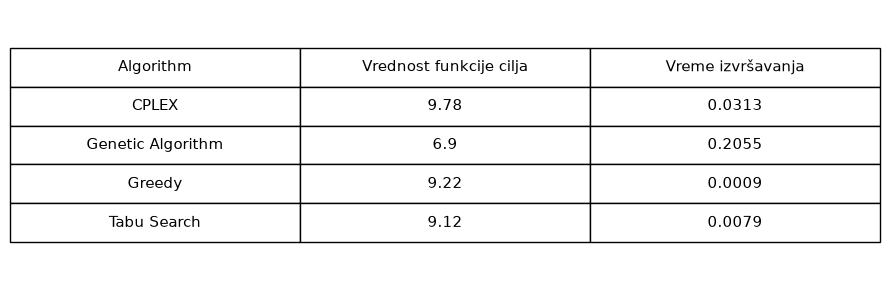

Tabela je sačuvana u: /home/hpdeb/Documents/RI/maximum-independent-set/results/medium_summary.png


In [18]:
import matplotlib.pyplot as plt

# Kopija tabele za prikaz
table_data = summary.copy()

# Zaokruživanje
table_data["Vrednost funkcije cilja"] = (
    table_data["Vrednost funkcije cilja"].round(2)
)

table_data["Vreme izvršavanja"] = (
    table_data["Vreme izvršavanja"].round(4)
)

# Kreiranje slike
fig, ax = plt.subplots(figsize=(9, 3))

ax.axis("off")

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

plt.tight_layout()

# Putanja do results foldera
output_path = project_root / "results" / "medium_summary.png"

# Čuvanje slike
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Tabela je sačuvana u: {output_path}")